# Cryptocurrency Price Prediction using Machine Learning and LSTM

## Introduction
Cryptocurrency markets are highly volatile and predicting their price movements is an important task in financial analytics. In this notebook, Bitcoin price data is used to build predictive models using two approaches: traditional machine learning algorithms and deep learning using Long Short-Term Memory (LSTM) networks.

#### Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

#### Download Cryptocurrency Data

In [3]:
data = yf.download("BTC-USD",
                   start="2017-01-01",
                   end="2024-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2017-01-01,998.325012,1003.080017,958.698975,963.658020,147775008
2017-01-02,1021.750000,1031.390015,996.702026,998.617004,222184992
2017-01-03,1043.839966,1044.079956,1021.599976,1021.599976,185168000
2017-01-04,1154.729980,1159.420044,1044.400024,1044.400024,344945984
2017-01-05,1013.380005,1191.099976,910.416992,1156.729980,510199008


#### Select Closing Price

In [4]:
data = data[['Close']]

#### Data Visualization

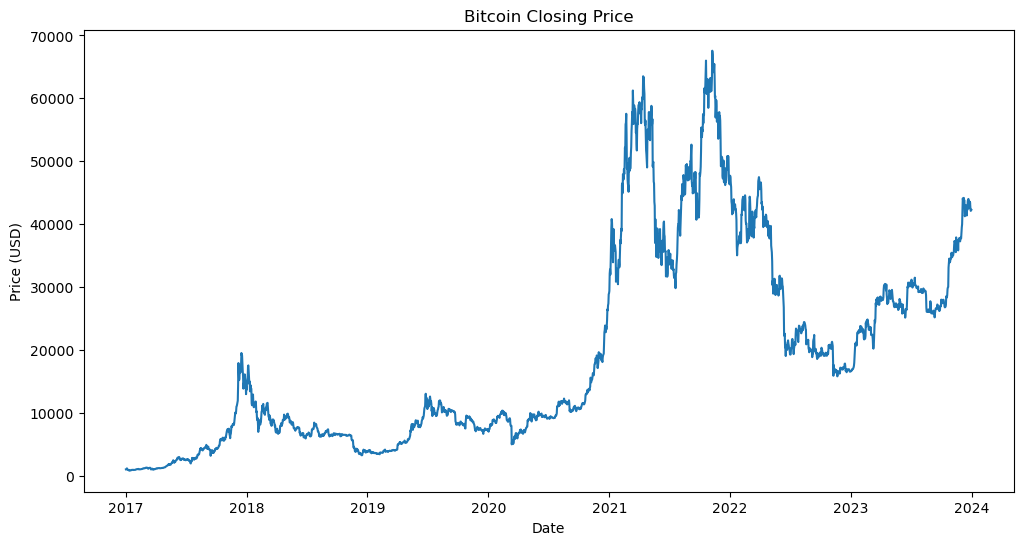

In [5]:
plt.figure(figsize=(12,6))
plt.plot(data['Close'])
plt.title("Bitcoin Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

## Prediction using Machine Learning Algorithm

#### Feature Engineering

In [6]:
data['Prev_Close'] = data['Close'].shift(1)

data = data.dropna()

#### Prepare Training Data

In [7]:
X = data[['Prev_Close']]
y = data['Close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

#### Train Random Forest Model

In [8]:
rf_model = RandomForestRegressor(n_estimators=100)

rf_model.fit(X_train, y_train)

RandomForestRegressor()

#### Make Predictions

In [9]:
rf_predictions = rf_model.predict(X_test)

#### Evaluate Model

In [10]:
rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
print("RMSE:", rmse)

RMSE: 1122.8839554614822


#### Visualization of ML Predictions

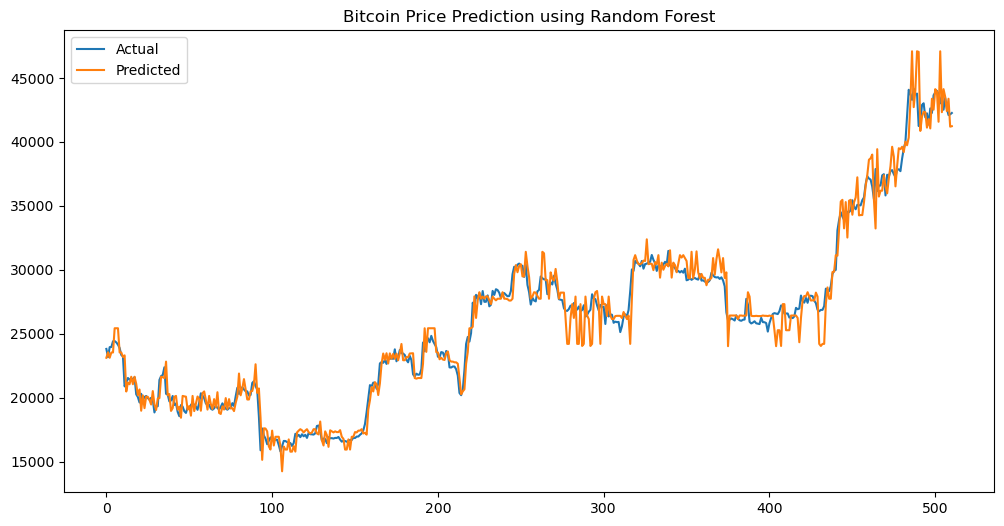

In [11]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')
plt.plot(rf_predictions, label='Predicted')

plt.title("Bitcoin Price Prediction using Random Forest")
plt.legend()

plt.show()

## Prediction using LSTM

#### Data Scaling

In [12]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data[['Close']])

#### Train Test Split

In [13]:
training_data_len = int(len(scaled_data) * 0.8)

train_data = scaled_data[0:training_data_len]

#### Create Time Series Data

In [14]:
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i,0])
    y_train.append(train_data[i,0])

x_train = np.array(x_train)
y_train = np.array(y_train)

#### Reshape Data for LSTM

In [15]:
x_train = np.reshape(x_train,
                     (x_train.shape[0],
                      x_train.shape[1],
                      1))

#### Build LSTM Model

In [16]:
model = Sequential()

model.add(LSTM(50, return_sequences=True,
               input_shape=(x_train.shape[1],1)))

model.add(Dropout(0.2))

model.add(LSTM(50, return_sequences=False))

model.add(Dropout(0.2))

model.add(Dense(25))
model.add(Dense(1))

#### Compile and Train Model

In [17]:
model.compile(optimizer='adam',
              loss='mean_squared_error')

model.fit(x_train, y_train,
          epochs=20,
          batch_size=32)


Epoch 1/20

62/62 [==============================] - 17s 93ms/step - loss: 0.0119
Epoch 2/20
62/62 [==============================] - 6s 94ms/step - loss: 0.0030
Epoch 3/20
62/62 [==============================] - 6s 94ms/step - loss: 0.0026
Epoch 4/20
62/62 [==============================] - 6s 94ms/step - loss: 0.0020
Epoch 5/20
62/62 [==============================] - 6s 98ms/step - loss: 0.0019
Epoch 6/20
62/62 [==============================] - 6s 95ms/step - loss: 0.0018
Epoch 7/20
62/62 [==============================] - 6s 95ms/step - loss: 0.0019
Epoch 8/20
62/62 [==============================] - 6s 97ms/step - loss: 0.0018
Epoch 9/20
62/62 [==============================] - 6s 95ms/step - loss: 0.0015
Epoch 10/20
62/62 [==============================] - 6s 98ms/step - loss: 0.0016
Epoch 11/20
62/62 [==============================] - 6s 92ms/step - loss: 0.0014
Epoch 12/20
62/62 [==============================] - 6s 95ms/step - loss: 0.0014
Epoch 13/20
62/62 [===============

#### Prepare Test Data

In [18]:
test_data = scaled_data[training_data_len - 60:]

x_test = []
y_test = scaled_data[training_data_len:]

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i,0])

x_test = np.array(x_test)

x_test = np.reshape(x_test,
                    (x_test.shape[0],
                     x_test.shape[1],
                     1))

#### Make Predictions

In [19]:
predictions = model.predict(x_test)

predictions = scaler.inverse_transform(predictions)

16/16 [==============================] - 3s 38ms/step


#### Visualization of LSTM Predictions

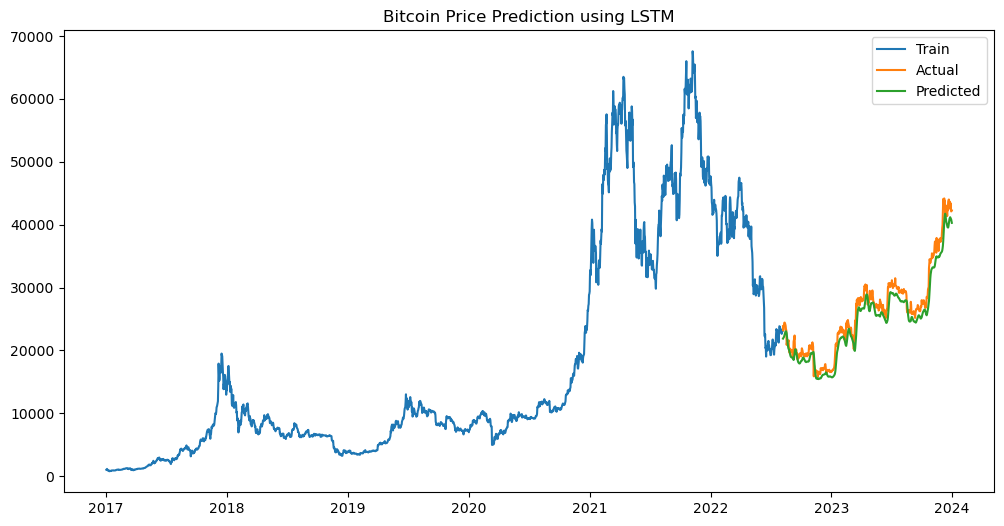

In [20]:
train = data[:training_data_len]

valid = data[training_data_len:].copy()
valid['Predictions'] = predictions

plt.figure(figsize=(12,6))

plt.plot(train['Close'])
plt.plot(valid[['Close','Predictions']])

plt.title("Bitcoin Price Prediction using LSTM")

plt.legend(['Train','Actual','Predicted'])

plt.show()

### Key Insights
Random Forest captures basic relationships but struggles with time-series patterns.

LSTM performs better for sequential financial data.

Cryptocurrency prices show strong volatility making prediction difficult.

## Conclusion
This project explored cryptocurrency price prediction using both traditional machine learning and deep learning techniques. While the Random Forest model provided baseline predictions, the LSTM model was better at capturing temporal patterns in Bitcoin price movements. Future improvements can include additional features such as trading volume, technical indicators, and sentiment analysis.